# Hedonic Pricing Regression
**Thesis: What Makes Vietnamese Groceries Expensive?**

This notebook runs OLS hedonic regressions to estimate implicit price premiums for product attributes (brand, import origin, health claims, pack size) in Vietnamese online grocery data.

## Pipeline
1. Load `output/product_features.csv` (built by `src/build_product_dataset.py` + `src/nlp_features.py`)
2. Filter to products with extractable size (regression requires unit-normalized DV)
3. Run pooled OLS + per-category OLS
4. Robustness: 3 date snapshot averages
5. Diagnostics: VIF, cluster-robust SE, R² decomposition

In [1]:
import sys
sys.path.insert(0, '..')  # so 'src' and 'config' are importable

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 30)

## 1. Load Data

In [2]:
df = pd.read_csv('../output/product_features.csv')
print(f"Loaded: {len(df)} products across {df['parent_category'].nunique()} categories")
df.head(3)

Loaded: 2280 products across 10 categories


,product_name,unit,subcategory,parent_category,avg_final_price,avg_marked_price,days_observed,promo_rate,avg_discount_depth,price_volatility,n_price_changes,max_daily_jump_pct,ever_promoted,always_promoted,marked_price_changes,...,has_health_claim,has_freshness_claim,name_length,unit_type,pack_count,uncertain_pack_count,size_ml,size_g,ln_pack_size,price_per_100ml,price_per_100g,ln_price_per_unit,marked_price_per_100ml,marked_price_per_100g,ln_marked_price_per_unit
0,Bơ lạt Anchor gói 227g,Miếng,Bơ Sữa - Phô Mai,Sữa Tươi,124981.8182,137500.0000,66,0.5455,0.1669,0.0971,3,0.2569,1,0,1,...,0,0,5,count,1,False,NaN,227.0000,5.4250,NaN,55058.0697,10.9161,NaN,60572.6872,11.0116
1,Bơ lạt Paysan Breton hộp 250g,Hộp,Bơ Sữa - Phô Mai,Sữa Tươi,174000.0000,174000.0000,47,0.0000,NaN,0.0000,1,0.0000,0,0,1,...,0,0,6,count,1,False,NaN,250.0000,5.5215,NaN,69600.0000,11.1505,NaN,69600.0000,11.1505
2,Bơ lạt Presiden hộp 250g,Hộp,Bơ Sữa - Phô Mai,Sữa Tươi,181000.0000,181000.0000,52,0.0000,NaN,0.0000,1,0.0000,0,0,1,...,0,0,5,count,1,False,NaN,250.0000,5.5215,NaN,72400.0000,11.1900,NaN,72400.0000,11.1900


In [3]:
# Overview of key features
feature_cols = [
    'is_branded', 'is_premium', 'is_high_recognition',
    'is_import', 'is_house_brand',
    'has_health_claim', 'has_freshness_claim',
    'ln_pack_size', 'pack_count', 'name_length',
    'ln_price_per_unit', 'ln_marked_price_per_unit',
]
# Only include columns that exist (backward compat)
feature_cols = [c for c in feature_cols if c in df.columns]
df[feature_cols].describe().round(3)

,is_branded,is_premium,is_high_recognition,is_import,is_house_brand,has_health_claim,has_freshness_claim,ln_pack_size,pack_count,name_length,ln_price_per_unit,ln_marked_price_per_unit
count,2280.0000,2280.0000,2280.0000,2280.0000,2280.0000,2280.0000,2280.0000,2075.0000,2280.0000,2280.0000,2075.0000,2075.0000
mean,0.6930,0.1980,0.3100,0.0430,0.0090,0.0540,0.0680,5.1780,2.0360,7.7830,9.8200,9.8620
std,0.4620,0.3990,0.4630,0.2030,0.0960,0.2250,0.2510,1.0910,4.8920,2.5320,1.0330,1.0220
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.6930,1.0000,1.0000,7.2340,7.3060
25%,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,4.5000,1.0000,6.0000,9.0580,9.1050
50%,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,5.2880,1.0000,8.0000,9.7850,9.8260
75%,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,5.8580,1.0000,9.0000,10.4710,10.4860
max,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,8.5170,48.0000,18.0000,13.5610,13.5610


## 2. Descriptive Statistics (Table 1)
Mean prices, promotion rates, and feature rates by category.

In [4]:
table1 = df.groupby('parent_category').agg(
    n_products=('product_name', 'count'),
    avg_final_price=('avg_final_price', 'mean'),
    avg_marked_price=('avg_marked_price', 'mean'),
    promo_rate=('promo_rate', 'mean'),
    avg_discount_pct=('avg_discount_depth', 'mean'),
    pct_branded=('is_branded', 'mean'),
    pct_import=('is_import', 'mean'),
    pct_health=('has_health_claim', 'mean'),
).round(3)

table1['avg_discount_pct'] = (table1['avg_discount_pct'] * 100).round(1)
table1['promo_rate']       = (table1['promo_rate'] * 100).round(1)
table1['pct_branded']      = (table1['pct_branded'] * 100).round(1)
table1['pct_import']       = (table1['pct_import'] * 100).round(1)
table1['pct_health']       = (table1['pct_health'] * 100).round(1)

print("Table 1: Descriptive Statistics by Category")
table1

Table 1: Descriptive Statistics by Category


,n_products,avg_final_price,avg_marked_price,promo_rate,avg_discount_pct,pct_branded,pct_import,pct_health
parent_category,,,,,,,,
Bánh Kẹo,583,63245.5440,67449.1110,17.5000,19.1000,56.3000,2.9000,3.6000
Chăm Sóc Bé,58,141955.4630,147681.0340,29.2000,16.3000,93.1000,0.0000,19.0000
Gia Vị,300,67878.5500,72663.5610,36.0000,15.7000,92.7000,0.7000,3.7000
Mì - Thực Phẩm Ăn Liền,226,66025.7010,67626.1670,30.0000,14.2000,83.6000,7.1000,0.0000
Rau - Củ - Trái Cây,251,68390.4320,69893.8000,13.1000,18.0000,7.6000,13.5000,0.4000
Sữa Tươi,346,79971.4470,82126.0210,33.6000,12.5000,89.0000,3.5000,19.7000
Thực Phẩm Chế Biến,172,55236.0260,56489.0850,15.8000,16.4000,84.3000,4.7000,1.7000
Thực Phẩm Khô,182,65029.8850,67576.4360,27.3000,15.1000,75.3000,0.5000,2.2000
Thực Phẩm Đông Lạnh,137,90638.8730,92013.7710,9.7000,16.2000,73.0000,5.8000,0.0000


## 3. Regression Sample
Keep products where size was extractable (required for unit-normalized DV).

In [5]:
from src.preparation import prepare_regression_sample

reg_df, reg_df_clean = prepare_regression_sample(df)

print(f"Regression sample: {len(reg_df_clean)} products ({len(reg_df_clean)/len(df)*100:.1f}% of total)")
print(f"Coverage by category:")
print(reg_df_clean.groupby('parent_category').size().rename('n_in_sample'))

Regression sample: 2032 products (89.1% of total)
Coverage by category:
parent_category
Bánh Kẹo                  550
Chăm Sóc Bé                34
Gia Vị                    294
Mì - Thực Phẩm Ăn Liền    224
Rau - Củ - Trái Cây       124
Sữa Tươi                  330
Thực Phẩm Chế Biến        167
Thực Phẩm Khô             170
Thực Phẩm Đông Lạnh       131
Trứng - Đậu Hũ              8
Name: n_in_sample, dtype: int64


## 4. Pooled OLS — Final Price DV (Table 2a)

```
ln(final_price/unit) = α + β1·is_branded + β2·is_premium + β3·is_high_recognition
                      + β4·is_import + β5·is_house_brand
                      + β6·ln_pack_size + β7·pack_count
                      + β8·has_health_claim + β9·has_freshness_claim
                      + β10·name_length + subcategory_FE + ε
```

Brand quadrant decomposition:
- `is_branded` = baseline brand premium (Local & Value brands vs. generic)
- `is_premium` = additional premium for premium-price quadrants (Prestige Leader + Niche Professional)
- `is_high_recognition` = additional effect of high market recognition (Household Giant + Prestige Leader)

SEs clustered by subcategory.

In [6]:
FORMULA = (
    'ln_price_per_unit ~ '
    'is_branded + is_premium + is_high_recognition + '
    'is_import + is_house_brand + '
    'ln_pack_size + pack_count + '
    'has_health_claim + has_freshness_claim + '
    'name_length + C(subcategory)'
)

model_final = smf.ols(FORMULA, data=reg_df_clean).fit(
    cov_type='cluster',
    cov_kwds={'groups': reg_df_clean['subcategory']},
)

print(model_final.summary2())

                              Results: Ordinary least squares
Model:                       OLS                       Adj. R-squared:             0.641    
Dependent Variable:          ln_price_per_unit         AIC:                        3614.3687
Date:                        2026-03-23 11:25          BIC:                        3883.9740
No. Observations:            2032                      Log-Likelihood:             -1759.2  
Df Model:                    47                        F-statistic:                341.9    
Df Residuals:                1984                      Prob (F-statistic):         2.73e-33 
R-squared:                   0.649                     Scale:                      0.33875  
--------------------------------------------------------------------------------------------
                                             Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
--------------------------------------------------------------------------------------------
Intercep

/Users/my/Online Food Price/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 47, but rank is 10
  warnings.warn('covariance of constraints does not have full '


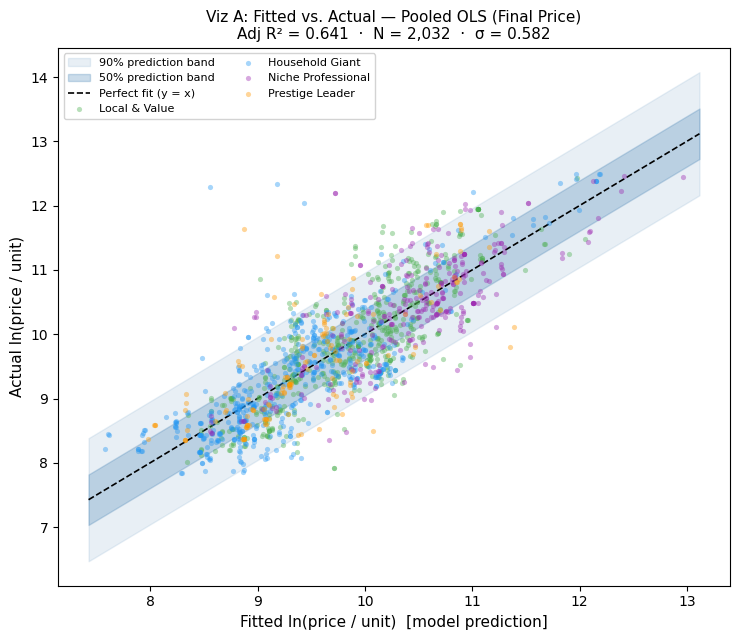

In [7]:
## --- Visualization A: Fitted vs. Actual ---
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

_QUAD_COLORS_A = {
    'generic': '#9E9E9E', 'local_value': '#4CAF50',
    'household_giant': '#2196F3', 'niche_professional': '#9C27B0',
    'prestige_leader': '#FF9800',
}
_QUAD_DISPLAY_A = {
    'generic': 'Generic', 'local_value': 'Local & Value',
    'household_giant': 'Household Giant', 'niche_professional': 'Niche Professional',
    'prestige_leader': 'Prestige Leader',
}

fitted = model_final.fittedvalues
actual = reg_df_clean['ln_price_per_unit']
sigma  = np.sqrt(model_final.mse_resid)

x_lo = fitted.min() - 0.15
x_hi = fitted.max() + 0.15
x_grid_a = np.linspace(x_lo, x_hi, 300)

fig, ax = plt.subplots(figsize=(7.5, 6.5))

# 90% PI band around perfect-fit line
ax.fill_between(x_grid_a, x_grid_a - 1.645*sigma, x_grid_a + 1.645*sigma,
                alpha=0.12, color='steelblue', label='90% prediction band')
# 50% PI band
ax.fill_between(x_grid_a, x_grid_a - 0.674*sigma, x_grid_a + 0.674*sigma,
                alpha=0.28, color='steelblue', label='50% prediction band')
# Perfect-fit diagonal
ax.plot(x_grid_a, x_grid_a, 'k--', linewidth=1.2, label='Perfect fit (y = x)')

# Scatter colored by brand_quadrant (already in reg_df_clean from product_features.csv)
for quad in ['generic', 'local_value', 'household_giant', 'niche_professional', 'prestige_leader']:
    mask = reg_df_clean['brand_quadrant'] == quad
    if mask.sum() == 0:
        continue
    ax.scatter(fitted[mask], actual[mask], c=_QUAD_COLORS_A[quad],
               alpha=0.4, s=14, label=_QUAD_DISPLAY_A[quad], zorder=3, linewidths=0)

ax.set_xlabel('Fitted ln(price / unit)  [model prediction]', fontsize=11)
ax.set_ylabel('Actual ln(price / unit)', fontsize=11)
ax.set_title(
    f'Viz A: Fitted vs. Actual — Pooled OLS (Final Price)\n'
    f'Adj R² = {model_final.rsquared_adj:.3f}  ·  N = {len(reg_df_clean):,}  ·  σ = {sigma:.3f}',
    fontsize=11)
ax.legend(fontsize=8, loc='upper left', ncol=2, framealpha=0.85)
plt.tight_layout()
plt.show()


## 5. Pooled OLS — Marked Price DV (Table 2b)
Compare β coefficients with final_price model to see if promotions erode premiums.

In [8]:
# 1. Update the columns list to include your NEW dependent variable
columns_in_model_marked = [
    'ln_marked_price_per_unit', 'is_branded', 'is_premium', 'is_high_recognition',
    'is_import', 'is_house_brand',
    'ln_pack_size', 'pack_count', 'has_health_claim', 'has_freshness_claim',
    'name_length', 'subcategory'
]

# 2. Drop NaNs to ensure the model data and cluster arrays match lengths perfectly
reg_df_marked_clean = reg_df.dropna(subset=columns_in_model_marked).copy()

# 3. Force the cluster group to be uniform strings to fix the float vs. str error
reg_df_marked_clean['subcategory'] = reg_df_marked_clean['subcategory'].astype(str)

# 4. Create your new formula
FORMULA_MARKED = FORMULA.replace('ln_price_per_unit', 'ln_marked_price_per_unit')

# 5. Run the model using the CLEANED dataframe (both in data= and cov_kwds=)
model_marked = smf.ols(FORMULA_MARKED, data=reg_df_marked_clean).fit(
    cov_type='cluster',
    cov_kwds={'groups': reg_df_marked_clean['subcategory']},
)

print(model_marked.summary2())

                              Results: Ordinary least squares
Model:                    OLS                            Adj. R-squared:           0.636    
Dependent Variable:       ln_marked_price_per_unit       AIC:                      3597.4746
Date:                     2026-03-23 11:25               BIC:                      3867.0798
No. Observations:         2032                           Log-Likelihood:           -1750.7  
Df Model:                 47                             F-statistic:              335.0    
Df Residuals:             1984                           Prob (F-statistic):       3.97e-33 
R-squared:                0.645                          Scale:                    0.33595  
--------------------------------------------------------------------------------------------
                                             Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
--------------------------------------------------------------------------------------------
Intercep

/Users/my/Online Food Price/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 47, but rank is 10
  warnings.warn('covariance of constraints does not have full '


## 6. Side-by-Side Coefficient Comparison (Table 2)
Marked price vs. final price premiums — shows whether promotions close the gap.

In [9]:
KEY_VARS = [
    'is_branded', 'is_premium', 'is_high_recognition',
    'is_import', 'is_house_brand',
    'ln_pack_size', 'pack_count',
    'has_health_claim', 'has_freshness_claim', 'name_length',
]

def extract_coefs(model, label):
    coef = model.params[KEY_VARS]
    pval = model.pvalues[KEY_VARS]
    se   = model.bse[KEY_VARS]
    stars = pval.map(lambda p: '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else '')))
    result = pd.DataFrame({
        f'β ({label})': coef.round(4).astype(str) + stars,
        f'SE ({label})': se.round(4),
    })
    return result

t2 = pd.concat([
    extract_coefs(model_marked, 'marked'),
    extract_coefs(model_final,  'final'),
], axis=1)

# Add R2 row
r2_row = pd.DataFrame({
    'β (marked)': [f"{model_marked.rsquared_adj:.3f}"],
    'SE (marked)': [''],
    'β (final)':  [f"{model_final.rsquared_adj:.3f}"],
    'SE (final)':  [''],
}, index=['Adj R²'])

table2 = pd.concat([t2, r2_row])
print("Table 2: Hedonic Regression — Marked Price vs. Final Price")
print(f"N = {len(reg_df)}")
print("\nInterpretation of brand quadrant coefficients:")
print("  β(is_branded)           = Local & Value brand premium vs. generic")
print("  β(is_branded)+β(is_premium) = Niche Professional premium vs. generic")
print("  β(is_branded)+β(is_high_recognition) = Household Giant premium vs. generic")
print("  β(is_branded)+β(is_premium)+β(is_high_recognition) = Prestige Leader premium vs. generic")
table2

Table 2: Hedonic Regression — Marked Price vs. Final Price
N = 2032

Interpretation of brand quadrant coefficients:
  β(is_branded)           = Local & Value brand premium vs. generic
  β(is_branded)+β(is_premium) = Niche Professional premium vs. generic
  β(is_branded)+β(is_high_recognition) = Household Giant premium vs. generic
  β(is_branded)+β(is_premium)+β(is_high_recognition) = Prestige Leader premium vs. generic


,β (marked),SE (marked),β (final),SE (final)
is_branded,0.009,0.0760,-0.0026,0.0765
is_premium,0.4225***,0.0568,0.4292***,0.0591
is_high_recognition,-0.269***,0.0616,-0.2791***,0.0652
is_import,0.0075,0.1239,-0.0225,0.1253
is_house_brand,0.0315,0.0580,-0.1918***,0.0581
ln_pack_size,-0.354***,0.0388,-0.3658***,0.0403
pack_count,-0.0204***,0.0062,-0.0195***,0.0061
has_health_claim,-0.0134,0.1084,-0.0084,0.1165
has_freshness_claim,-0.0172,0.0676,-0.0252,0.0680
name_length,0.0029,0.0137,0.004,0.0139


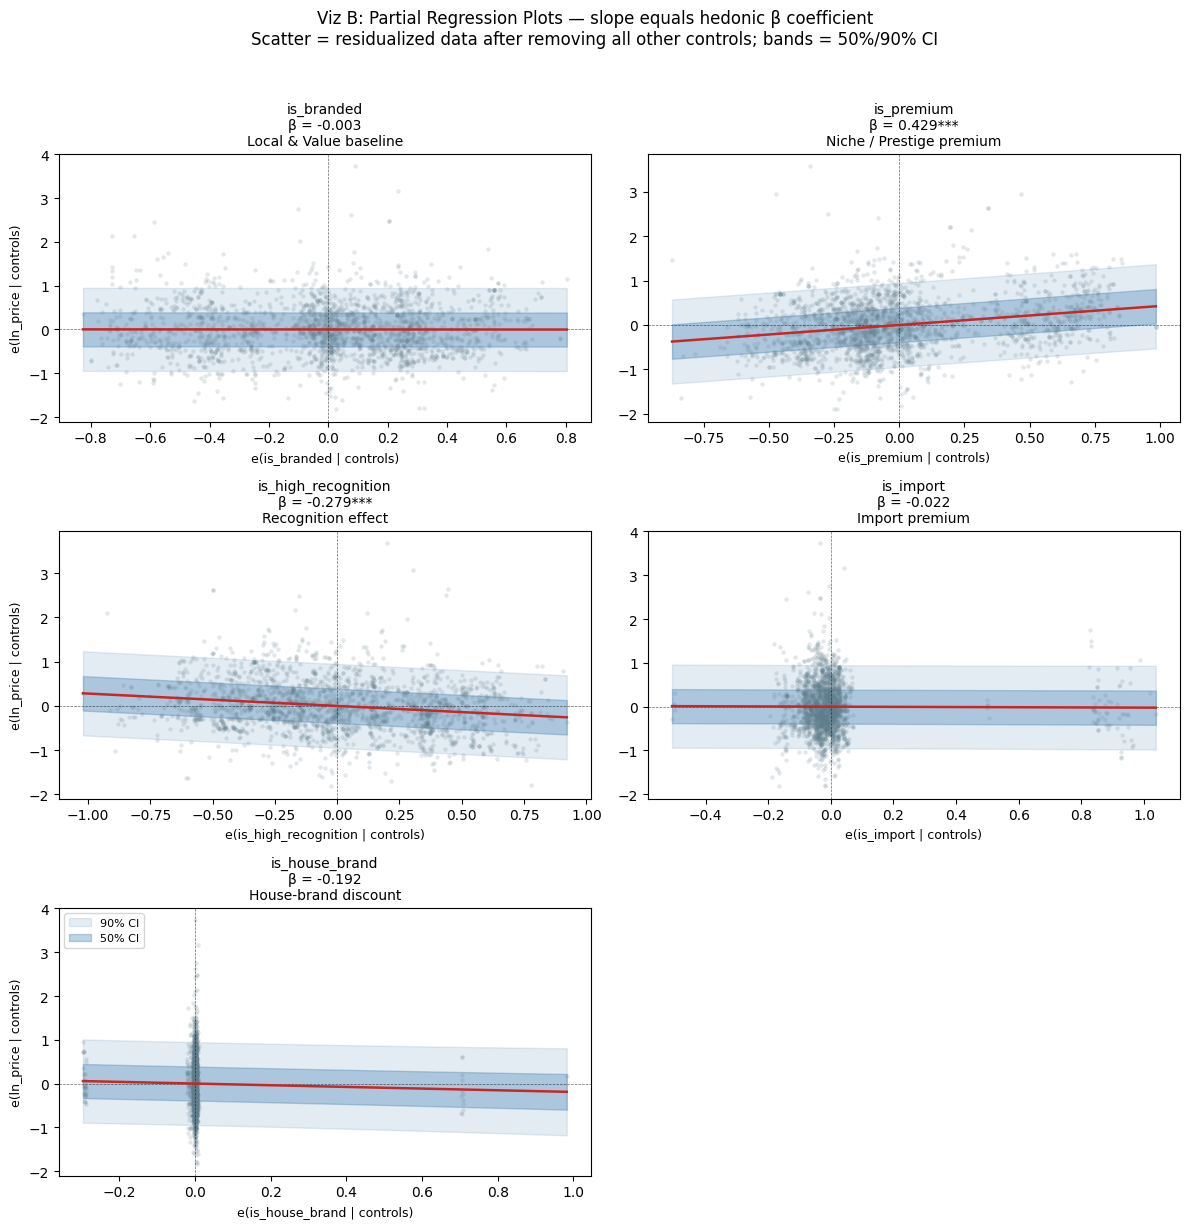

In [10]:
## --- Visualization B: Partial Regression Plots (Added Variable Plots) ---
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

_BRAND_VARS_B = ['is_branded', 'is_premium', 'is_high_recognition', 'is_import', 'is_house_brand']
_BETA_LABELS_B = {
    'is_branded':          'Local & Value baseline',
    'is_premium':          'Niche / Prestige premium',
    'is_high_recognition': 'Recognition effect',
    'is_import':           'Import premium',
    'is_house_brand':      'House-brand discount',
}

# 1. Change to 3 rows, 2 columns and adjust figure size for a grid
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

# 2. Flatten the 2D array of axes to easily iterate over it
axes_flat = axes.flatten()

for i, (ax, var) in enumerate(zip(axes_flat[:5], _BRAND_VARS_B)):
    _others_b = [v for v in KEY_VARS if v != var]
    _others_f_b = ' + '.join(_others_b) + ' + C(subcategory)'

    _m_y_b = smf.ols(f'ln_price_per_unit ~ {_others_f_b}', data=reg_df_clean).fit()
    _m_x_b = smf.ols(f'{var} ~ {_others_f_b}', data=reg_df_clean).fit()

    _rx = _m_x_b.resid.values
    _ry = _m_y_b.resid.values

    _Xrx = sm.add_constant(_rx)
    _part_b = sm.OLS(_ry, _Xrx).fit()

    _xlo_b, _xhi_b = _rx.min(), _rx.max()
    _xg_b = np.linspace(_xlo_b, _xhi_b, 200)
    _Xg_b = sm.add_constant(_xg_b)

    _p90_b = _part_b.get_prediction(_Xg_b).summary_frame(alpha=0.1)
    _p50_b = _part_b.get_prediction(_Xg_b).summary_frame(alpha=0.5)

    ax.fill_between(_xg_b, _p90_b['obs_ci_lower'], _p90_b['obs_ci_upper'],
                    alpha=0.15, color='steelblue', label='90% CI')
    ax.fill_between(_xg_b, _p50_b['obs_ci_lower'], _p50_b['obs_ci_upper'],
                    alpha=0.35, color='steelblue', label='50% CI')
    ax.scatter(_rx, _ry, alpha=0.18, s=10, color='#607D8B', zorder=2, linewidths=0)
    ax.plot(_xg_b, _p90_b['mean'], color='#C62828', linewidth=1.8, zorder=3)
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.6)
    ax.axvline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.6)

    # Note: Maintaining the .iloc fix from the previous step
    _beta_b = _part_b.params[1]
    _pval_b = _part_b.pvalues[1]
    _stars_b = '***' if _pval_b < 0.001 else ('**' if _pval_b < 0.01 else ('*' if _pval_b < 0.05 else ''))

    ax.set_title(f'{var}\nβ = {_beta_b:.3f}{_stars_b}\n{_BETA_LABELS_B[var]}', fontsize=10)
    ax.set_xlabel(f'e({var} | controls)', fontsize=9)
    
    # 4. Add y-label only to the leftmost column (indices 0, 2, 4)
    if i % 2 == 0:
        ax.set_ylabel('e(ln_price | controls)', fontsize=9)

# 3. Hide the 6th empty subplot
axes_flat[5].axis('off')

# Put the legend on the 5th plot
axes_flat[4].legend(fontsize=8, loc='upper left')

fig.suptitle(
    'Viz B: Partial Regression Plots — slope equals hedonic β coefficient\n'
    'Scatter = residualized data after removing all other controls; bands = 50%/90% CI',
    fontsize=12, y=1.02)

plt.tight_layout()
plt.show()

## 7. Per-Category Regressions (Table 3)
Brand premium varies by category — test the Dairy vs. Veg_Fruit gradient.

In [11]:
FOCUS_CATS = ['Sữa các loại', 'Rau-Củ-Trái cây', 'Thực phẩm khô', 'Thực Phẩm Chế Biến']

# Use all categories with at least 20 products in regression sample
cat_counts = reg_df.groupby('parent_category').size()
eligible_cats = cat_counts[cat_counts >= 20].index.tolist()
print(f"Categories with ≥20 products in sample: {eligible_cats}")

SIMPLE_FORMULA = (
    'ln_price_per_unit ~ '
    'is_branded + is_premium + is_high_recognition + '
    'is_import + is_house_brand + '
    'ln_pack_size + pack_count + '
    'has_health_claim + has_freshness_claim + name_length'
)

cat_results = {}
for cat in eligible_cats:
    sub = reg_df[reg_df['parent_category'] == cat].copy()
    # Drop rows with missing quadrant features
    sub = sub.dropna(subset=['is_premium', 'is_high_recognition'])
    if sub['subcategory'].nunique() > 1:
        formula = SIMPLE_FORMULA + ' + C(subcategory)'
    else:
        formula = SIMPLE_FORMULA
    try:
        m = smf.ols(formula, data=sub).fit()
        cat_results[cat] = m
        print(f"{cat}: n={len(sub)}, adj_R²={m.rsquared_adj:.3f}")
    except Exception as e:
        print(f"{cat}: failed — {e}")

Categories with ≥20 products in sample: ['Bánh Kẹo', 'Chăm Sóc Bé', 'Gia Vị', 'Mì - Thực Phẩm Ăn Liền', 'Rau - Củ - Trái Cây', 'Sữa Tươi', 'Thực Phẩm Chế Biến', 'Thực Phẩm Khô', 'Thực Phẩm Đông Lạnh']
Bánh Kẹo: n=550, adj_R²=0.375
Chăm Sóc Bé: n=34, adj_R²=0.753
Gia Vị: n=294, adj_R²=0.528
Mì - Thực Phẩm Ăn Liền: n=224, adj_R²=0.224
Rau - Củ - Trái Cây: n=124, adj_R²=0.549
Sữa Tươi: n=330, adj_R²=0.689
Thực Phẩm Chế Biến: n=167, adj_R²=0.396
Thực Phẩm Khô: n=170, adj_R²=0.829
Thực Phẩm Đông Lạnh: n=131, adj_R²=0.533


In [12]:
# Compile brand + import premiums across categories
rows = []
for cat, m in cat_results.items():
    row = {'category': cat, 'n': int(m.nobs), 'adj_R2': round(m.rsquared_adj, 3)}
    for var in ['is_branded', 'is_premium', 'is_high_recognition', 'is_import', 'is_house_brand', 'has_health_claim']:
        if var in m.params:
            row[var]          = round(m.params[var], 4)
            row[f'{var}_pval'] = round(m.pvalues[var], 4)
    rows.append(row)

table3 = pd.DataFrame(rows).set_index('category')
print("Table 3: Cross-Category Premium Estimates (ln_price_per_unit DV)")
print("  is_branded = Local & Value baseline; is_premium / is_high_recognition = quadrant adjustments")
table3

Table 3: Cross-Category Premium Estimates (ln_price_per_unit DV)
  is_branded = Local & Value baseline; is_premium / is_high_recognition = quadrant adjustments


,n,adj_R2,is_branded,is_branded_pval,is_premium,is_premium_pval,is_high_recognition,is_high_recognition_pval,is_import,is_import_pval,is_house_brand,is_house_brand_pval,has_health_claim,has_health_claim_pval
category,,,,,,,,,,,,,,
Bánh Kẹo,550,0.3750,0.1190,0.0872,0.3734,0.0000,-0.4319,0.0000,-0.0642,0.7025,-0.0000,0.0000,0.0999,0.4910
Chăm Sóc Bé,34,0.7530,0.5200,0.2297,0.1018,0.7146,-0.2244,0.3523,0.0000,0.0000,0.0000,0.0000,-0.0278,0.9002
Gia Vị,294,0.5280,-0.1970,0.1845,0.7101,0.0000,-0.3063,0.0007,0.1000,0.8003,-0.0000,0.0000,0.3822,0.0295
Mì - Thực Phẩm Ăn Liền,224,0.2240,-0.1330,0.2536,0.3122,0.0004,0.0847,0.3369,0.1028,0.4767,0.0000,0.6135,0.0000,NaN
Rau - Củ - Trái Cây,124,0.5490,-0.1111,0.5811,-0.0000,0.0000,-0.0000,0.0000,1.1623,0.0000,-0.3929,0.0417,0.0000,NaN
Sữa Tươi,330,0.6890,-0.1846,0.1098,0.4554,0.0000,-0.1751,0.0364,-0.2958,0.1176,-0.0000,0.8186,-0.1409,0.1255
Thực Phẩm Chế Biến,167,0.3960,0.1658,0.2186,0.5028,0.0036,-0.3608,0.0119,-0.6124,0.0128,0.0000,0.8269,0.0937,0.7757
Thực Phẩm Khô,170,0.8290,0.0525,0.6541,0.1517,0.2997,-0.4460,0.0001,0.6676,0.2005,0.0000,0.3634,0.1067,0.7055
Thực Phẩm Đông Lạnh,131,0.5330,-0.2111,0.0196,0.2948,0.0028,0.1274,0.2516,-0.1648,0.2450,-0.0000,0.0867,0.0000,NaN


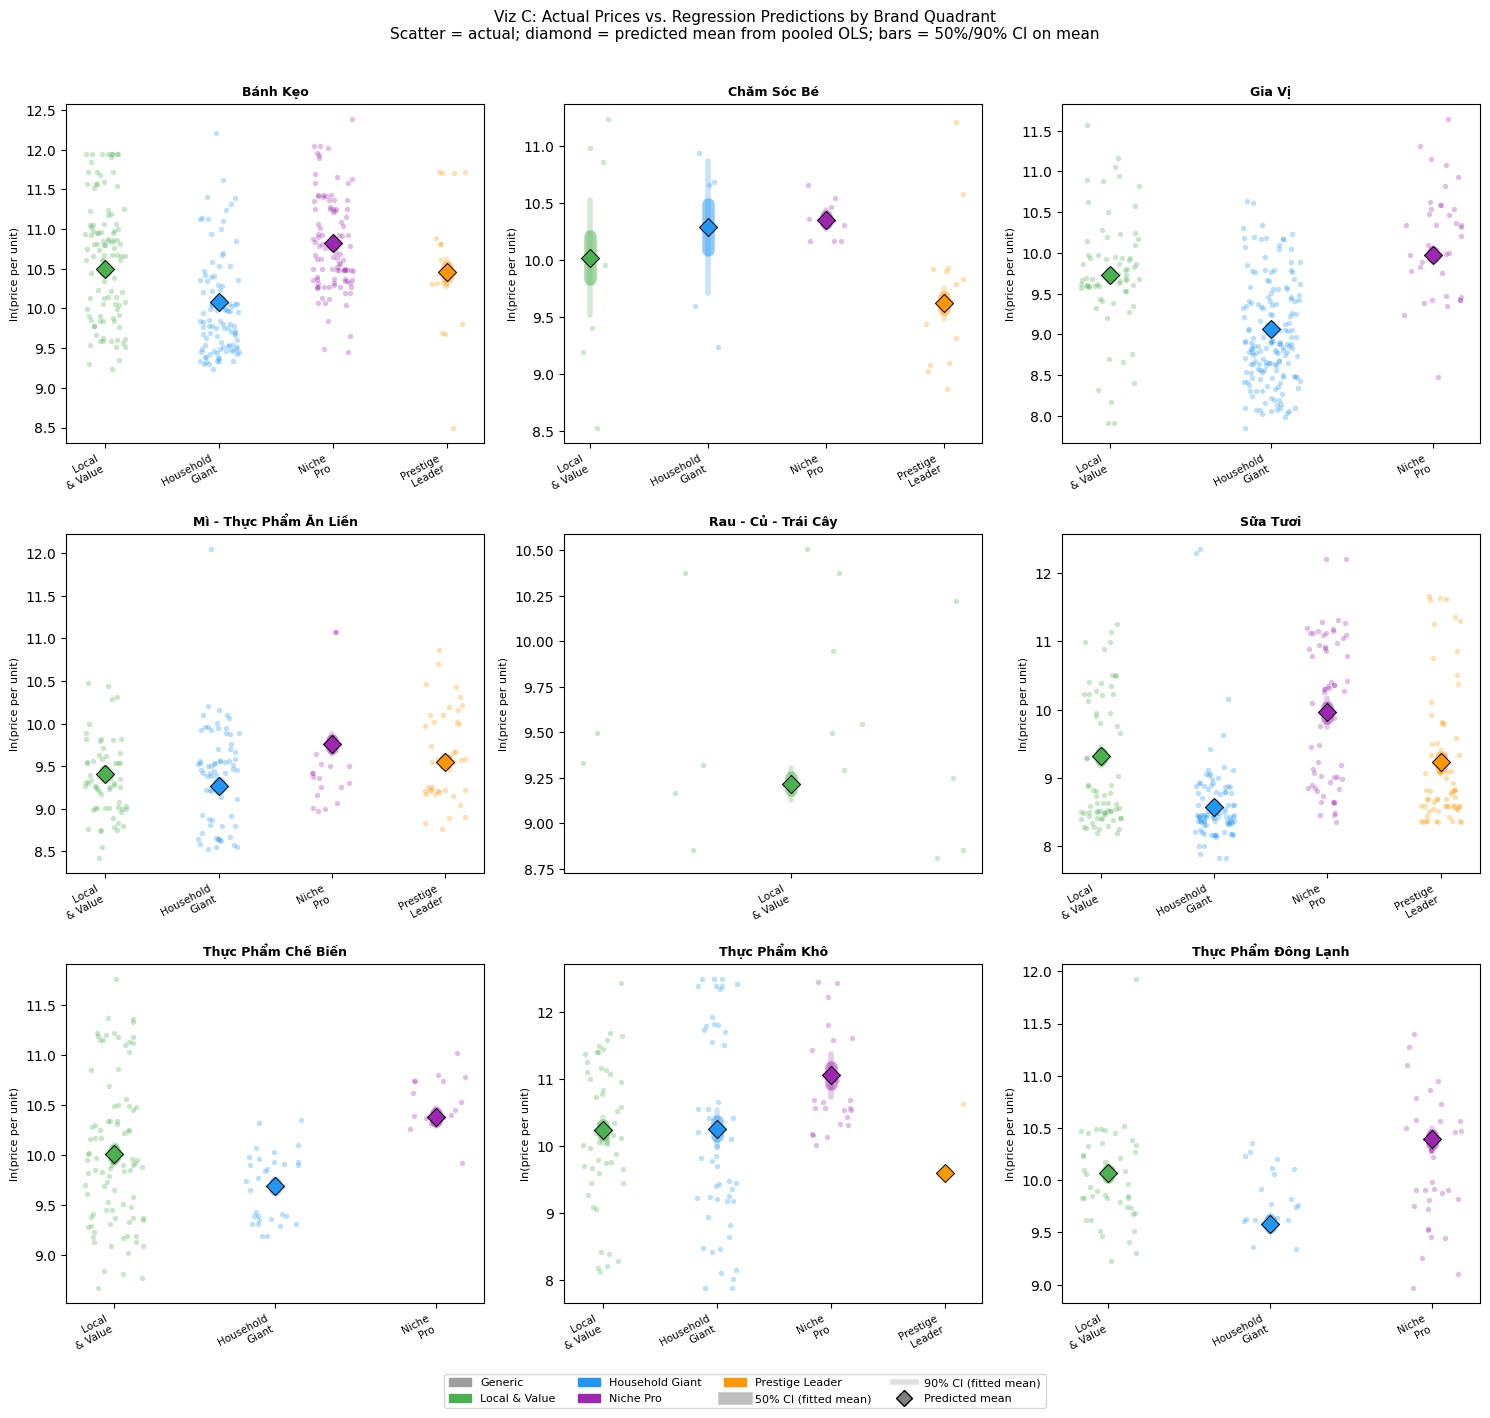

In [13]:
## --- Visualization C: Actual Prices vs. Regression Predictions by Brand Quadrant ---
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import t as _t_dist_c

_QUAD_ORDER_C = ['generic', 'local_value', 'household_giant', 'niche_professional', 'prestige_leader']
_QUAD_LABELS_C = {
    'generic': 'Generic', 'local_value': 'Local\n& Value',
    'household_giant': 'Household\nGiant', 'niche_professional': 'Niche\nPro',
    'prestige_leader': 'Prestige\nLeader',
}
_QUAD_COLORS_C = {
    'generic': '#9E9E9E', 'local_value': '#4CAF50',
    'household_giant': '#2196F3', 'niche_professional': '#9C27B0',
    'prestige_leader': '#FF9800',
}

_rc = reg_df_clean.copy()
_rc['fitted_c'] = model_final.fittedvalues
# brand_quadrant already present from product_features.csv

_eligible_c = sorted(cat_results.keys())
_nc = len(_eligible_c)
_ncols_c = 3
_nrows_c = int(np.ceil(_nc / _ncols_c))
_rng_c = np.random.default_rng(42)

fig, axes = plt.subplots(_nrows_c, _ncols_c, figsize=(15, 4.5 * _nrows_c), sharey=False)
axes = axes.flatten()

for i, cat in enumerate(_eligible_c):
    ax = axes[i]
    _dcat = _rc[_rc['parent_category'] == cat]
    _quads = [q for q in _QUAD_ORDER_C if q in _dcat['brand_quadrant'].values]

    for j, quad in enumerate(_quads):
        _dq = _dcat[_dcat['brand_quadrant'] == quad]
        _jitter = _rng_c.uniform(-0.18, 0.18, size=len(_dq))

        # Actual prices
        ax.scatter(j + _jitter, _dq['ln_price_per_unit'],
                   c=_QUAD_COLORS_C[quad], alpha=0.3, s=15, zorder=2, linewidths=0)

        # Fitted mean + CI on mean
        _fv_c = _dq['fitted_c'].values
        _n_q  = len(_fv_c)
        _mean_fit = _fv_c.mean()
        if _n_q >= 3:
            _se_c  = _fv_c.std(ddof=1) / np.sqrt(_n_q)
            _ci90c = _t_dist_c.ppf(0.95, df=_n_q - 1) * _se_c
            _ci50c = _t_dist_c.ppf(0.75, df=_n_q - 1) * _se_c
        else:
            _ci90c = _ci50c = 0.0

        # 90% CI bar
        ax.plot([j, j], [_mean_fit - _ci90c, _mean_fit + _ci90c],
                color=_QUAD_COLORS_C[quad], linewidth=4, alpha=0.25,
                solid_capstyle='round', zorder=3)
        # 50% CI bar
        ax.plot([j, j], [_mean_fit - _ci50c, _mean_fit + _ci50c],
                color=_QUAD_COLORS_C[quad], linewidth=9, alpha=0.5,
                solid_capstyle='round', zorder=4)
        # Diamond at predicted mean
        ax.scatter(j, _mean_fit, color=_QUAD_COLORS_C[quad], s=85, marker='D',
                   edgecolors='black', linewidths=0.7, zorder=5)

    ax.set_title(cat, fontsize=9, fontweight='bold')
    ax.set_ylabel('ln(price per unit)', fontsize=8)
    ax.set_xticks(range(len(_quads)))
    ax.set_xticklabels([_QUAD_LABELS_C[q] for q in _quads],
                       rotation=28, ha='right', fontsize=7.5)

for k in range(i + 1, len(axes)):
    axes[k].set_visible(False)

_hC = [mpatches.Patch(color=_QUAD_COLORS_C[q], label=_QUAD_LABELS_C[q].replace('\n', ' '))
       for q in _QUAD_ORDER_C]
_hC += [
    plt.Line2D([0],[0], color='gray', linewidth=9,  alpha=0.5,  label='50% CI (fitted mean)'),
    plt.Line2D([0],[0], color='gray', linewidth=4,  alpha=0.25, label='90% CI (fitted mean)'),
    plt.Line2D([0],[0], marker='D', color='w', markerfacecolor='gray',
               markeredgecolor='black', markersize=8, label='Predicted mean'),
]
fig.legend(handles=_hC, loc='lower center', ncol=4, fontsize=8, bbox_to_anchor=(0.5, -0.03))
fig.suptitle(
    'Viz C: Actual Prices vs. Regression Predictions by Brand Quadrant\n'
    'Scatter = actual; diamond = predicted mean from pooled OLS; bars = 50%/90% CI on mean',
    fontsize=11, y=1.01)
plt.tight_layout()
plt.show()


## 8. Diagnostics

In [14]:
# VIF — multicollinearity check
X_vif = reg_df[[
    'is_branded', 'is_premium', 'is_high_recognition',
    'is_import', 'is_house_brand',
    'ln_pack_size', 'pack_count',
    'has_health_claim', 'has_freshness_claim', 'name_length',
]].dropna()

X_vif_const = sm.add_constant(X_vif)
vif_df = pd.DataFrame({
    'feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif_const.values, i+1) for i in range(X_vif.shape[1])],
})
print("VIF (rule of thumb: VIF > 10 indicates multicollinearity)")
print(vif_df.to_string(index=False))

VIF (rule of thumb: VIF > 10 indicates multicollinearity)
            feature    VIF
         is_branded 1.4607
         is_premium 1.1778
is_high_recognition 1.3380
          is_import 1.0279
     is_house_brand 1.0235
       ln_pack_size 1.0536
         pack_count 1.2092
   has_health_claim 1.0673
has_freshness_claim 1.0994
        name_length 1.3487


In [15]:
# Partial F-tests: brand block and health claim block
RESTRICTED_NO_BRAND = (
    'ln_price_per_unit ~ '
    'is_import + ln_pack_size + pack_count + '
    'has_health_claim + has_freshness_claim + name_length + C(subcategory)'
)
RESTRICTED_NO_HEALTH = (
    'ln_price_per_unit ~ '
    'is_branded + is_premium + is_high_recognition + '
    'is_import + is_house_brand + '
    'ln_pack_size + pack_count + name_length + C(subcategory)'
)

m_no_brand  = smf.ols(RESTRICTED_NO_BRAND,  data=reg_df).fit()
m_no_health = smf.ols(RESTRICTED_NO_HEALTH, data=reg_df).fit()
m_full      = smf.ols(FORMULA, data=reg_df).fit()  # no cluster for F-test

# F-statistic: (ΔR²/Δk) / ((1-R²_full)/(n-k_full))
def f_test(r_full, r_restricted, k_added, n, k_full):
    return ((r_full - r_restricted) / k_added) / ((1 - r_full) / (n - k_full - 1))

n = len(reg_df)
k = m_full.df_model

f_brand  = f_test(m_full.rsquared, m_no_brand.rsquared,  4, n, k)  # is_branded + is_premium + is_high_recognition + is_house_brand
f_health = f_test(m_full.rsquared, m_no_health.rsquared, 2, n, k)  # has_health + has_fresh

print(f"Partial F-test — Brand block (is_branded + is_premium + is_high_recognition + is_house_brand): F={f_brand:.2f}")
print(f"Partial F-test — Health claim block: F={f_health:.2f}")
print(f"(Critical value at α=0.05, df_num=4: ~2.37; df_num=2: ~3.0)")

Partial F-test — Brand block (is_branded + is_premium + is_high_recognition + is_house_brand): F=60.51
Partial F-test — Health claim block: F=0.09
(Critical value at α=0.05, df_num=4: ~2.37; df_num=2: ~3.0)


## 9. Robustness: 3 Date Snapshots
Re-run pooled regression on Dec 2025, Jan 2026, and Feb 2026 monthly averages separately.
Check if key coefficients are stable (β₁ brand premium should vary < 20%).

In [16]:
import sys, importlib
sys.path.insert(0, '..')

from pathlib import Path
from src.utils import PROJECT_ROOT, extract_date
from src.nlp_features import extract_features
from src.build_product_dataset import _extract_brand_name
from src.brand_quadrants import BRAND_QUADRANTS, is_premium as _is_prem, is_high_recognition as _is_hr

CATEGORIES = [
    "Dairy", "Baby_product", "Veg_Fruit", "Confectionary",
    "Dry_Food", "Egg_and_soy", "Frozen", "Instant_food",
    "Processed_food", "Spice",
]
NEEDED_COLS = {'product_name', 'unit', 'final_price', 'marked_price'}
MONTH_RANGES = {
    'Dec-2025': ('2025-12-01', '2025-12-31'),
    'Jan-2026': ('2026-01-01', '2026-01-31'),
    'Feb-2026': ('2026-02-01', '2026-02-28'),
}

def load_snapshot(month_start, month_end):
    """Build product-level dataset for a specific date window."""
    all_frames = []
    for cat in CATEGORIES:
        folder = PROJECT_ROOT / 'data' / cat
        csv_folder = folder / 'CSV'
        lookup_file = folder / 'cat_lookup_table.csv'
        frames = []
        for f in sorted(csv_folder.glob('*.csv')):
            d = extract_date(f.name)
            if not (month_start <= d <= month_end):
                continue
            try:
                df_ = pd.read_csv(f, usecols=lambda c: c in NEEDED_COLS)
                frames.append(df_)
            except Exception:
                pass
        if not frames:
            continue
        daily = pd.concat(frames, ignore_index=True)
        daily['final_price'] = pd.to_numeric(daily['final_price'], errors='coerce')
        daily['marked_price'] = pd.to_numeric(daily['marked_price'], errors='coerce')
        daily = daily[daily['final_price'] > 0]
        if lookup_file.exists():
            lkp = pd.read_csv(lookup_file, usecols=['product_name', 'subcategory', 'parent_category'])
            lkp = lkp.drop_duplicates(subset=['product_name'], keep='last')
            daily = daily.merge(lkp, on='product_name', how='left')
        else:
            daily['subcategory'] = 'Gia Vị'
            daily['parent_category'] = 'Gia Vị'
        grp = daily.groupby(['product_name', 'unit', 'subcategory', 'parent_category'], dropna=False)
        agg = grp.agg(
            avg_final_price=('final_price', 'mean'),
            avg_marked_price=('marked_price', 'mean'),
        ).reset_index()
        all_frames.append(agg)
    if not all_frames:
        return pd.DataFrame()
    return pd.concat(all_frames, ignore_index=True)


snapshot_models = {}
for month, (start, end) in MONTH_RANGES.items():
    snap = load_snapshot(start, end)
    if snap.empty:
        print(f"{month}: no data")
        continue
    # Add brand quadrant features before extract_features
    snap['brand_name'] = snap['product_name'].map(_extract_brand_name)
    snap['brand_quadrant'] = snap['brand_name'].map(BRAND_QUADRANTS).fillna('')
    snap['is_premium'] = snap['brand_quadrant'].apply(lambda q: _is_prem(q) if q else 0)
    snap['is_high_recognition'] = snap['brand_quadrant'].apply(lambda q: _is_hr(q) if q else 0)
    snap_feat = extract_features(snap)
    snap_reg = snap_feat.dropna(subset=['ln_price_per_unit', 'ln_pack_size', 'subcategory'])
    snap_reg = snap_reg[np.isfinite(snap_reg['ln_price_per_unit'])]
    if len(snap_reg) < 30:
        print(f"{month}: too few obs ({len(snap_reg)})")
        continue
    try:
        m = smf.ols(FORMULA, data=snap_reg).fit(
            cov_type='cluster',
            cov_kwds={'groups': snap_reg['subcategory'].astype(str)},
        )
        snapshot_models[month] = m
        print(f"{month}: n={len(snap_reg)}, adj_R²={m.rsquared_adj:.3f}, "
              f"β_brand={m.params.get('is_branded', float('nan')):.4f}, "
              f"β_premium={m.params.get('is_premium', float('nan')):.4f}, "
              f"β_high_recog={m.params.get('is_high_recognition', float('nan')):.4f}")
    except Exception as e:
        print(f"{month}: {e}")

# Stability check across months
stability = pd.DataFrame({
    m: {v: mod.params.get(v, np.nan) for v in ['is_branded', 'is_premium', 'is_high_recognition']}
    for m, mod in snapshot_models.items()
}).T
print("\nBrand quadrant coefficient stability across months:")
print(stability.round(4))

Dec-2025: n=1240, adj_R²=0.665, β_brand=-0.1077, β_premium=0.4431, β_high_recog=-0.3014


Jan-2026: n=1250, adj_R²=0.672, β_brand=-0.1060, β_premium=0.4675, β_high_recog=-0.3147


Feb-2026: n=1971, adj_R²=0.654, β_brand=-0.0214, β_premium=0.4393, β_high_recog=-0.2970

Brand quadrant coefficient stability across months:
          is_branded  is_premium  is_high_recognition
Dec-2025     -0.1077      0.4431              -0.3014
Jan-2026     -0.1060      0.4675              -0.3147
Feb-2026     -0.0214      0.4393              -0.2970


## 10. Export Tables for Thesis

In [17]:
out = PROJECT_ROOT / 'output'

table1.to_csv(out / 'thesis_table1_descriptive.csv', encoding='utf-8-sig')
table2.to_csv(out / 'thesis_table2_pooled_regression.csv', encoding='utf-8-sig')
table3.to_csv(out / 'thesis_table3_category_regression.csv', encoding='utf-8-sig')
vif_df.to_csv(out / 'thesis_table_vif.csv', index=False, encoding='utf-8-sig')

print("Saved 4 tables to output/")

Saved 4 tables to output/


## 11. Decision Tree Price Predictor

Predicts `avg_final_price` (VND) from structured product characteristics plus keyword features extracted from `product_name` via `CountVectorizer`. Complements the OLS hedonic regression by capturing interaction effects and providing intuitive price ranges per leaf.

In [18]:
## --- Section 11: Decision Tree Price Predictor ---
from src.preparation import prepare_tree_features
from src.tree_models import PercentileDecisionTree
from sklearn.tree import plot_tree, export_text
from sklearn.model_selection import cross_val_predict

_X_all, _feat_names, _y_all, _df_tree = prepare_tree_features(df)
print(f'Tree dataset: {len(_df_tree)} products, {_X_all.shape[1]} features')

# Fit — predict() returns p50; predict_percentiles() returns (n, 5)
_dt = PercentileDecisionTree(max_depth=5, min_samples_leaf=15)
_dt.fit(_X_all, _y_all)

# 5-fold CV (predict() → p50, compatible with cross_val_predict)
_y_cv   = cross_val_predict(_dt, _X_all, _y_all, cv=5)
_r2_cv  = 1 - np.sum((_y_all - _y_cv)**2) / np.sum((_y_all - _y_all.mean())**2)
_mae_cv = np.mean(np.abs(_y_all - _y_cv))
_med_cv = np.median(np.abs(_y_all - _y_cv))
print(f'\n5-fold CV results:')
print(f'  R\u00b2             = {_r2_cv:.3f}')
print(f'  MAE            = {_mae_cv:>12,.0f} VND')
print(f'  Median abs err = {_med_cv:>12,.0f} VND')
print(f'  Leaves: {_dt.get_n_leaves()}  |  Depth: {_dt.get_depth()}')

Tree dataset: 2280 products, 86 features



5-fold CV results:
  R²             = 0.134
  MAE            =       40,376 VND
  Median abs err =       19,023 VND
  Leaves: 16  |  Depth: 5


Top-10 price-premium keywords:
 keyword  n_with   mean_with  mean_without  pct_premium
   thùng      59 237785.3976    65692.5833     261.9669
     dầu      84 111294.8914    68571.8557      62.3040
      ăn      90 101868.3990    68842.1964      47.9738
     hạt      84  98350.3321    69067.0028      42.3984
    250g      57  98480.4373    69419.3347      41.8631
     khô      59  95984.1457    69459.4783      38.1873
    500g     130  88181.5138    69055.3345      27.6969
     tôm      73  86939.7532    69590.3779      24.9307
    việt      64  82889.1193    69777.8260      18.7901
gói 500g      55  81767.8220    69858.5779      17.0476

Bottom-5 price-discount keywords:
  keyword  n_with  mean_with  mean_without  pct_premium
     uống      77 37376.4462    71291.2300     -47.5722
    4 hộp     107 37540.4140    71751.3767     -47.6799
    lốc 4     105 36214.3475    71783.9354     -49.5509
chua uống      58 29864.6413    71197.3073     -58.0537
    snack      80 18910.1441    72008.

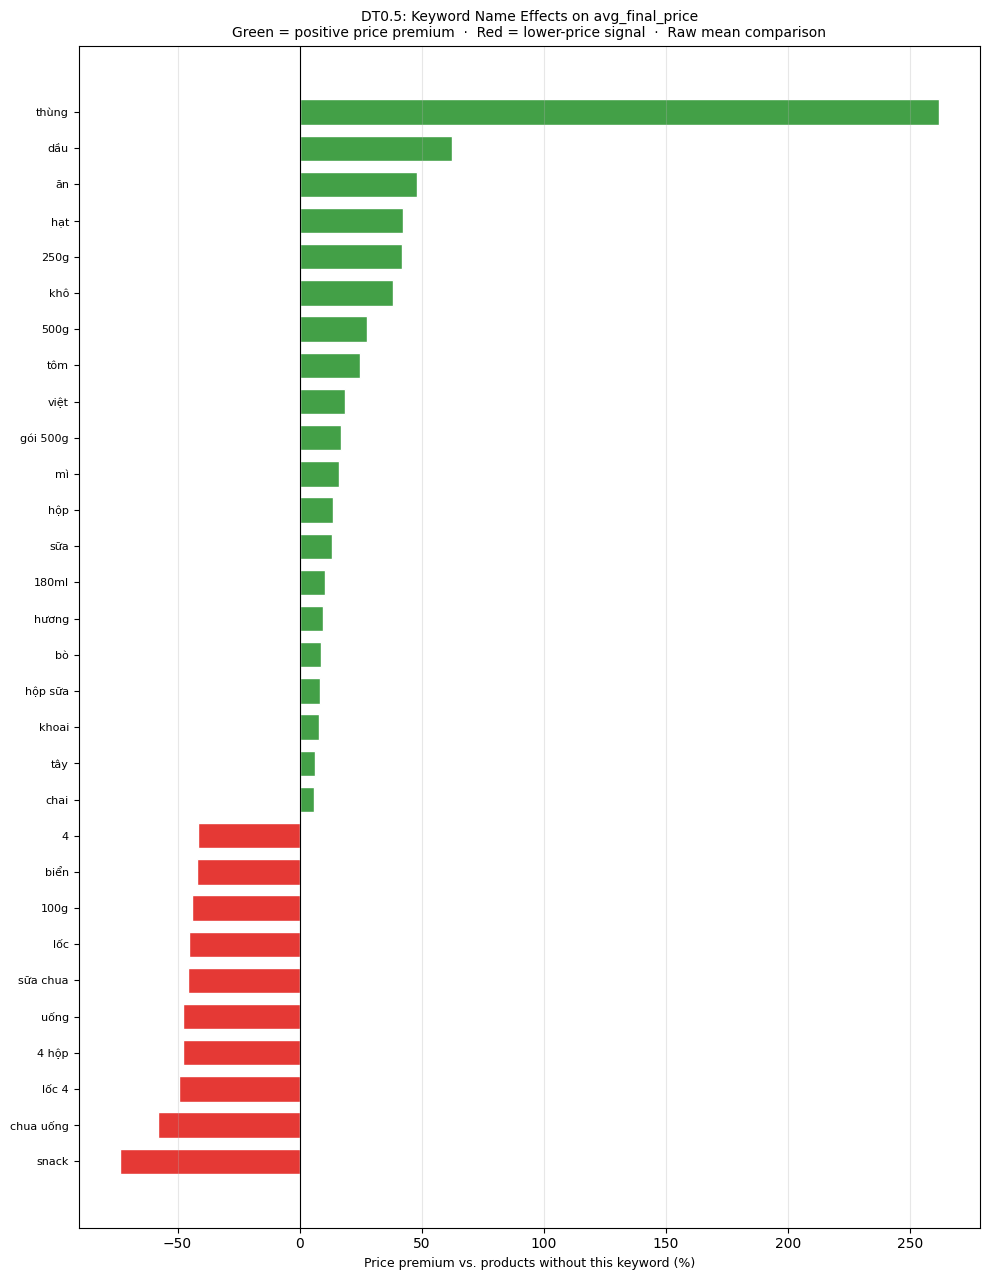

Keyword effects chart saved. (60 keywords analyzed)


In [19]:
## --- DT0.5: Keyword Price Effects ---
# For each keyword in the vocabulary, compare avg_final_price
# of products WITH vs. WITHOUT that keyword in their name.

_kw_start  = sum(1 for n in _feat_names if not n.startswith('kw:'))
_kw_tokens = [n[3:] for n in _feat_names if n.startswith('kw:')]

_kw_rows = []
for _i, _kw in enumerate(_kw_tokens):
    _mask = _X_all[:, _kw_start + _i].astype(bool)
    if _mask.sum() < 5 or (~_mask).sum() < 5:
        continue
    _mw = _y_all[_mask].mean()
    _mo = _y_all[~_mask].mean()
    _kw_rows.append({
        'keyword'     : _kw,
        'n_with'      : int(_mask.sum()),
        'mean_with'   : _mw,
        'mean_without': _mo,
        'pct_premium' : (_mw / _mo - 1) * 100,
    })

_kw_effects = (pd.DataFrame(_kw_rows)
               .sort_values('pct_premium', ascending=False)
               .reset_index(drop=True))

print('Top-10 price-premium keywords:')
print(_kw_effects.head(10)[['keyword','n_with','mean_with','mean_without','pct_premium']].to_string(index=False))
print('\nBottom-5 price-discount keywords:')
print(_kw_effects.tail(5)[['keyword','n_with','mean_with','mean_without','pct_premium']].to_string(index=False))

# Bar chart: top 20 premium + top 10 discount
_plot_df = pd.concat([_kw_effects.head(20), _kw_effects.tail(10)]).drop_duplicates().sort_values('pct_premium')
_colors  = ['#E53935' if v < 0 else '#43A047' for v in _plot_df['pct_premium']]

fig, ax = plt.subplots(figsize=(10, max(6, len(_plot_df) * 0.38 + 1.5)))
ax.barh(_plot_df['keyword'], _plot_df['pct_premium'], color=_colors, edgecolor='white', height=0.7)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Price premium vs. products without this keyword (%)', fontsize=9)
ax.set_title(
    'DT0.5: Keyword Name Effects on avg_final_price\n'
    'Green = positive price premium  \u00b7  Red = lower-price signal  \u00b7  Raw mean comparison',
    fontsize=10)
ax.tick_params(axis='y', labelsize=8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'output' / 'thesis_kw_effects.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Keyword effects chart saved. ({len(_kw_tokens)} keywords analyzed)')

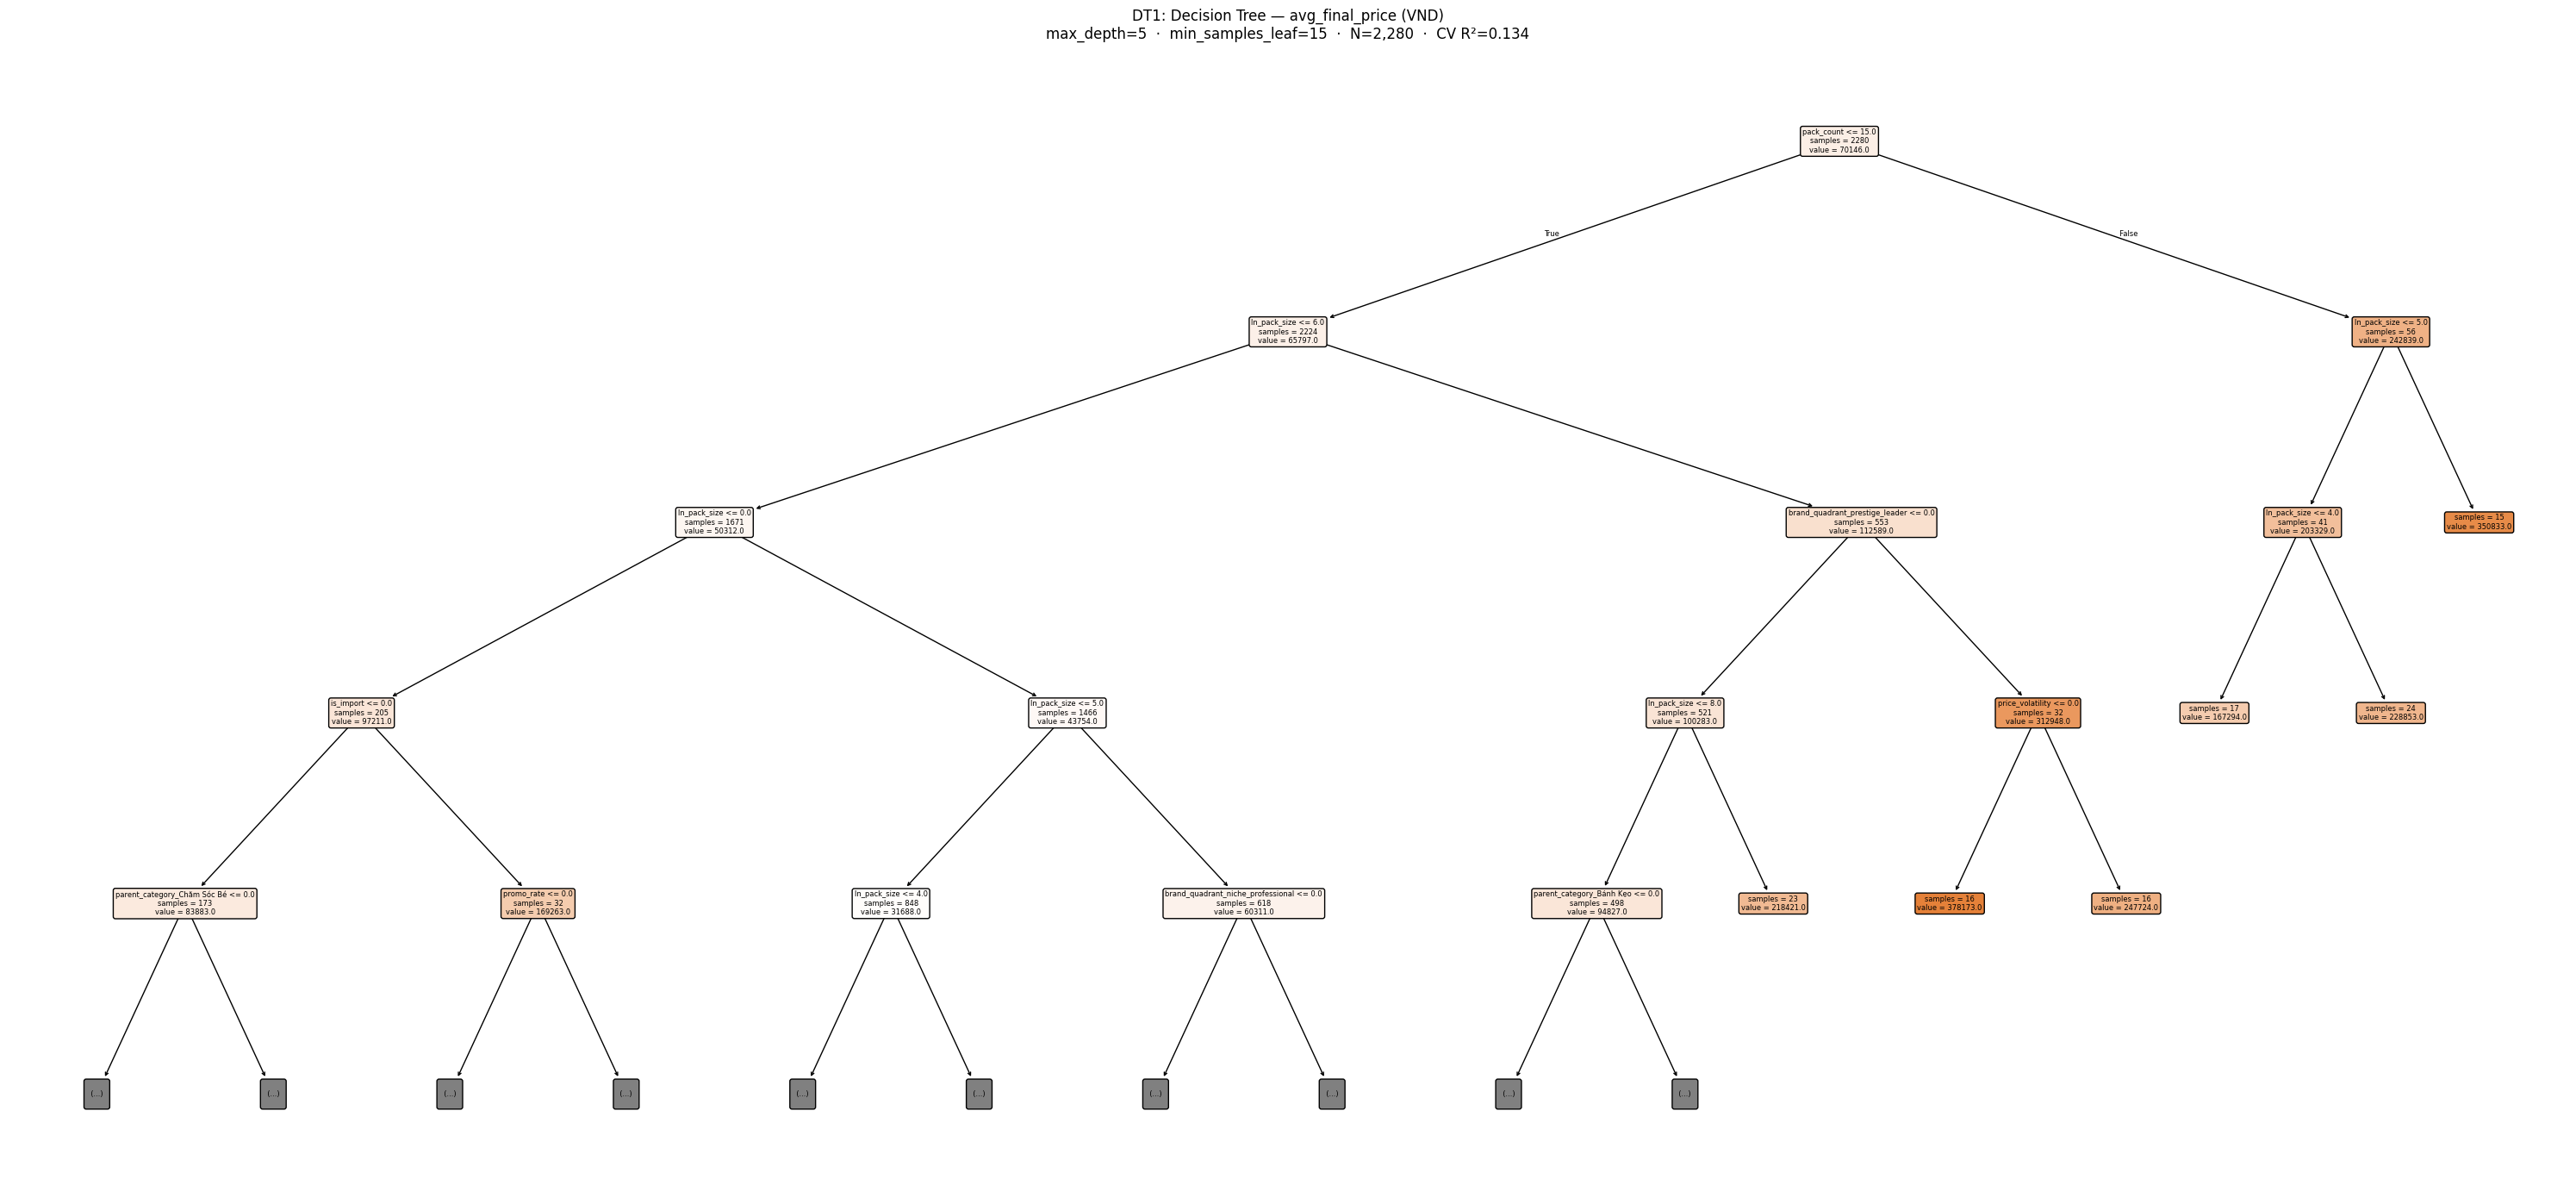

DT1 tree saved.

Top decision rules (first 3 levels):
|--- pack_count <= 15.00
|   |--- ln_pack_size <= 5.73
|   |   |--- ln_pack_size <= 0.35
|   |   |   |--- truncated branch of depth 3
|   |   |--- ln_pack_size >  0.35
|   |   |   |--- truncated branch of depth 3
|   |--- ln_pack_size >  5.73
|   |   |--- brand_quadrant_prestige_leader <= 0.50
|   |   |   |--- truncated branch of depth 3
|   |   |--- brand_quadrant_prestige_leader >  0.50
|   |   |   |--- truncated branch of depth 2
|--- pack_count >  15.00
|   |--- ln_pack_size <= 4.74
|   |   |--- ln_pack_size <= 4.33
|   |   |   |--- value: [167294.12]
|   |   |--- ln_pack_size >  4.33
|   |   |   |--- value: [228853.48]
|   |--- ln_pack_size >  4.74
|   |   |--- value: [350833.33]



In [20]:
## --- DT1: Decision Tree Diagram ---

fig, ax = plt.subplots(figsize=(30, 14))
plot_tree(
    _dt._tree,
    max_depth=4,
    feature_names=_feat_names,
    filled=True,
    impurity=False,
    precision=0,
    fontsize=6,  # FIX: Changed 6.5 to an integer (6)
    rounded=True,
    ax=ax,
)
ax.set_title(
    f'DT1: Decision Tree — avg_final_price (VND)\n'
    f'max_depth=5  ·  min_samples_leaf=15  ·  N={len(_df_tree):,}  ·  CV R²={_r2_cv:.3f}',
    fontsize=12)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'output' / 'thesis_dt_tree.png', dpi=120, bbox_inches='tight')
plt.show()
print('DT1 tree saved.')

print("\nTop decision rules (first 3 levels):")
print(export_text(_dt._tree, feature_names=_feat_names, max_depth=2))

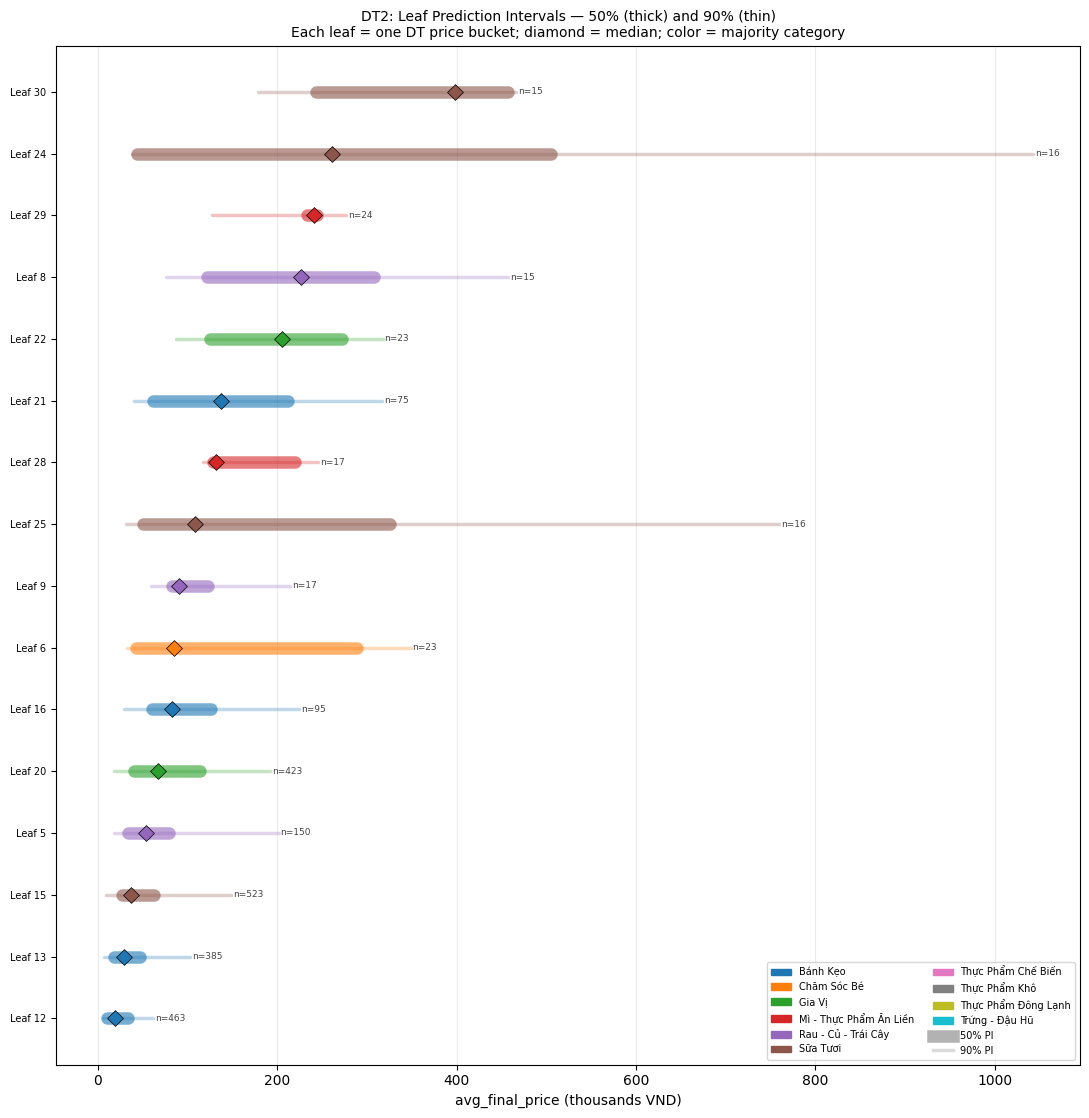

DT2 leaf PI chart saved.


In [21]:
## --- DT2: Leaf-Level Prediction Intervals ---
import matplotlib.patches as mpatches

# Pull percentiles directly from the model
_leaf_ids = _dt.apply(_X_all)
_all_pcts = _dt.predict_percentiles(_X_all)   # (n, 5): p5, p25, p50, p75, p95

_df_leaf = _df_tree.copy()
_df_leaf['leaf_id'] = _leaf_ids
_df_leaf[['pred_p5','pred_p25','pred_p50','pred_p75','pred_p95']] = _all_pcts

# One row per leaf: first-value percentiles (all samples in same leaf share same pcts)
_leaf_stats = (
    _df_leaf.groupby('leaf_id')
    .agg(
        p5     =('pred_p5',  'first'),
        p25    =('pred_p25', 'first'),
        p50    =('pred_p50', 'first'),
        p75    =('pred_p75', 'first'),
        p95    =('pred_p95', 'first'),
        n      =('avg_final_price', 'count'),
        top_cat=('parent_category', lambda x: x.mode()[0]),
    )
    .reset_index()
    .sort_values('p50')
    .reset_index(drop=True)
)

_CATS_DT = sorted([c for c in _df_tree['parent_category'].unique() if pd.notna(c)], key=str)
_CMAP_DT = dict(zip(_CATS_DT, plt.cm.tab10.colors[:len(_CATS_DT)]))
_n_leaves = len(_leaf_stats)

fig, ax = plt.subplots(figsize=(11, max(8, _n_leaves * 0.58 + 2)))
for rank, row in enumerate(_leaf_stats.itertuples()):
    _col = _CMAP_DT.get(row.top_cat, '#888888')
    ax.plot([row.p5 / 1000, row.p95 / 1000], [rank, rank],
            color=_col, linewidth=2.5, alpha=0.28, solid_capstyle='round')
    ax.plot([row.p25 / 1000, row.p75 / 1000], [rank, rank],
            color=_col, linewidth=9, alpha=0.6, solid_capstyle='round')
    ax.scatter(row.p50 / 1000, rank, color=_col, s=65, marker='D',
               edgecolors='black', linewidths=0.5, zorder=5)
    ax.text(row.p95 / 1000 + 2, rank, f'n={row.n}',
            va='center', fontsize=6.5, color='#444444')

ax.set_yticks(range(_n_leaves))
ax.set_yticklabels([f'Leaf {int(r.leaf_id)}' for r in _leaf_stats.itertuples()], fontsize=7)
ax.set_xlabel('avg_final_price (thousands VND)', fontsize=10)
ax.set_title(
    'DT2: Leaf Prediction Intervals \u2014 50% (thick) and 90% (thin)\n'
    'Each leaf = one DT price bucket; diamond = median; color = majority category',
    fontsize=10)
_h = [mpatches.Patch(color=_CMAP_DT[c], label=c) for c in _CATS_DT if c in _CMAP_DT]
_h += [
    plt.Line2D([0],[0], color='gray', linewidth=9,   alpha=0.6,  label='50% PI'),
    plt.Line2D([0],[0], color='gray', linewidth=2.5, alpha=0.28, label='90% PI'),
]
ax.legend(handles=_h, loc='lower right', fontsize=7, ncol=2)
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'output' / 'thesis_dt_leaf_intervals.png', dpi=150, bbox_inches='tight')
plt.show()
print('DT2 leaf PI chart saved.')

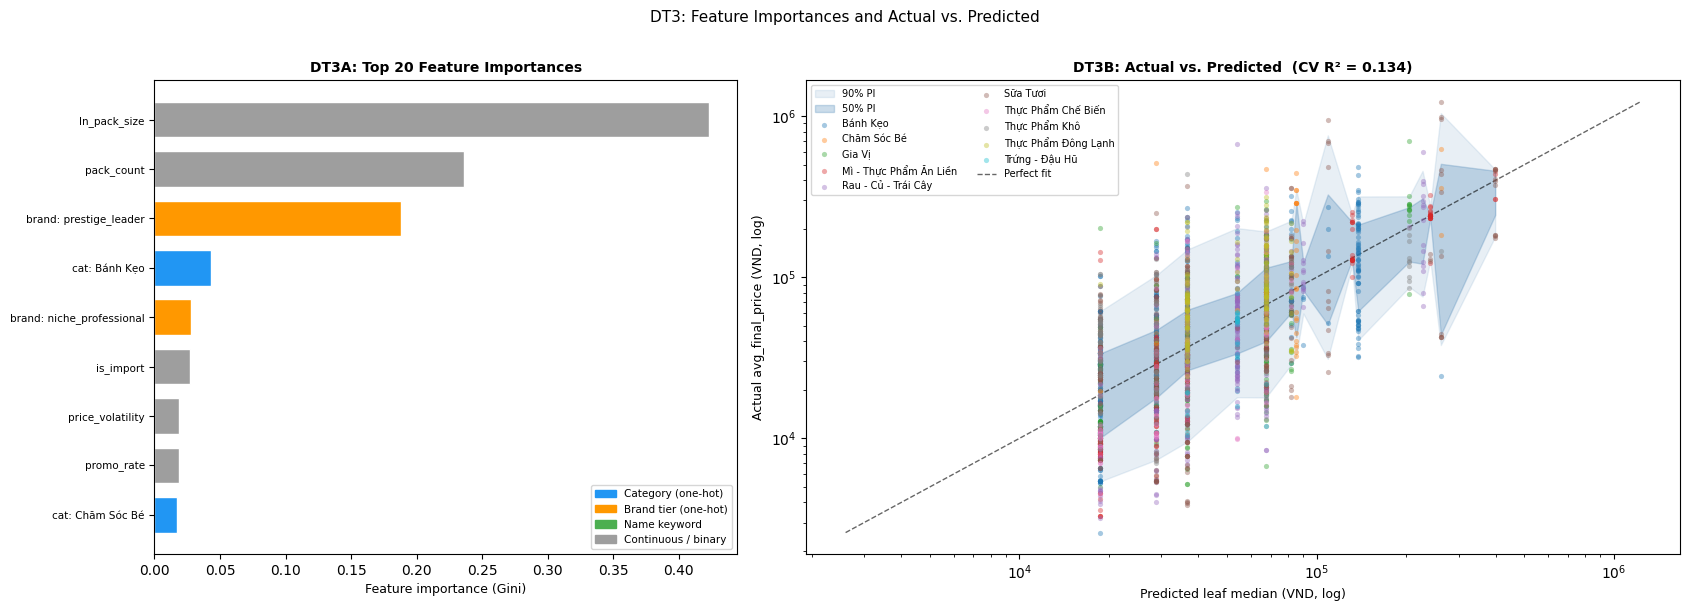

DT3 diagnostics saved.


In [22]:
## --- DT3: Feature Importances + Actual vs. Predicted ---

# Prediction intervals from the model
_all_pcts = _dt.predict_percentiles(_X_all)   # (n, 5): p5, p25, p50, p75, p95
_df_scat  = _df_tree.copy()
_df_scat['pred_p5'], _df_scat['pred_p25'], _df_scat['pred_p50'], \
_df_scat['pred_p75'], _df_scat['pred_p95'] = _all_pcts.T

# Feature importance: top 20
_imps = pd.Series(_dt.feature_importances_, index=_feat_names)
_imps = _imps[_imps > 0].sort_values().tail(20)

def _imp_color(name):
    if name.startswith('parent_category'): return '#2196F3'
    if name.startswith('brand_quadrant'):  return '#FF9800'
    if name.startswith('kw:'):             return '#4CAF50'
    return '#9E9E9E'

def _clean_name(name):
    if name.startswith('parent_category_'): return 'cat: ' + name[16:]
    if name.startswith('brand_quadrant_'):  return 'brand: ' + name[15:]
    return name

_colors_imp = [_imp_color(n) for n in _imps.index]
_labels_imp = [_clean_name(n) for n in _imps.index]

fig, (ax_imp, ax_sc) = plt.subplots(1, 2, figsize=(17, 6),
                                     gridspec_kw={'width_ratios': [2, 3]})

# Panel A: Feature importances
ax_imp.barh(_labels_imp, _imps.values, color=_colors_imp, edgecolor='white', height=0.72)
ax_imp.set_xlabel('Feature importance (Gini)', fontsize=9)
ax_imp.set_title('DT3A: Top 20 Feature Importances', fontsize=10, fontweight='bold')
ax_imp.tick_params(axis='y', labelsize=7.5)
import matplotlib.patches as mpatches
ax_imp.legend(handles=[
    mpatches.Patch(color='#2196F3', label='Category (one-hot)'),
    mpatches.Patch(color='#FF9800', label='Brand tier (one-hot)'),
    mpatches.Patch(color='#4CAF50', label='Name keyword'),
    mpatches.Patch(color='#9E9E9E', label='Continuous / binary'),
], fontsize=7.5, loc='lower right')

# Panel B: Actual vs predicted (log-log)
_band = (_df_scat.groupby('pred_p50')
         .agg(p5=('pred_p5','first'), p25=('pred_p25','first'),
              p75=('pred_p75','first'), p95=('pred_p95','first'))
         .reset_index().sort_values('pred_p50'))
ax_sc.fill_between(_band['pred_p50'], _band['p5'],  _band['p95'],
                   alpha=0.12, color='steelblue', label='90% PI')
ax_sc.fill_between(_band['pred_p50'], _band['p25'], _band['p75'],
                   alpha=0.28, color='steelblue', label='50% PI')
_CATS_DT2 = sorted([c for c in _df_tree['parent_category'].unique() if pd.notna(c)], key=str)
_CMAP_DT2 = dict(zip(_CATS_DT2, plt.cm.tab10.colors[:len(_CATS_DT2)]))
for cat in _CATS_DT2:
    _m = _df_scat['parent_category'] == cat
    ax_sc.scatter(_df_scat.loc[_m,'pred_p50'], _df_scat.loc[_m,'avg_final_price'],
                  c=_CMAP_DT2[cat], alpha=0.4, s=14, label=cat, zorder=3, linewidths=0)
_diag = np.logspace(np.log10(_df_scat['avg_final_price'].min()),
                    np.log10(_df_scat['avg_final_price'].max()), 100)
ax_sc.plot(_diag, _diag, 'k--', linewidth=1.0, alpha=0.6, label='Perfect fit')
ax_sc.set_xscale('log'); ax_sc.set_yscale('log')
ax_sc.set_xlabel('Predicted leaf median (VND, log)', fontsize=9)
ax_sc.set_ylabel('Actual avg_final_price (VND, log)', fontsize=9)
ax_sc.set_title(f'DT3B: Actual vs. Predicted  (CV R\u00b2 = {_r2_cv:.3f})', fontsize=10, fontweight='bold')
ax_sc.legend(fontsize=7, ncol=2, loc='upper left')
plt.suptitle('DT3: Feature Importances and Actual vs. Predicted', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'output' / 'thesis_dt_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print('DT3 diagnostics saved.')